In [199]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [78]:
df = pd.read_stata('Jloss.dta')
print(df.head())

      time    country  jloss
0  19901.0  argentina    NaN
1  19902.0  argentina    NaN
2  19903.0  argentina    NaN
3  19904.0  argentina    NaN
4  19911.0  argentina    NaN


In [79]:
# Mostrar todas las columnas y filas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print("\n--- Información del DataFrame (df.info()) ---")
df.info()

print("\n--- Estadísticas Descriptivas del DataFrame (df.describe()) ---")
print(df.describe(include='all'))


--- Información del DataFrame (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2470 entries, 0 to 2469
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   time     2470 non-null   float32
 1   country  2470 non-null   object 
 2   jloss    1559 non-null   float64
dtypes: float32(1), float64(1), object(1)
memory usage: 48.4+ KB

--- Estadísticas Descriptivas del DataFrame (df.describe()) ---
                time    country        jloss
count    2470.000000       2470  1559.000000
unique           NaN         19          NaN
top              NaN  argentina          NaN
freq             NaN        130          NaN
mean    20060.023438        NaN     8.228138
std        93.840630        NaN    10.187806
min     19901.000000        NaN     0.450000
25%     19981.000000        NaN     2.239745
50%     20061.500000        NaN     3.109989
75%     20142.000000        NaN     9.023910
max     20222.000000        NaN 

In [80]:
# Establecer opciones para mostrar todas las filas y columnas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("--- DataFrame Completo ---")
print(df)

--- DataFrame Completo ---
         time    country      jloss
0     19901.0  argentina        NaN
1     19902.0  argentina        NaN
2     19903.0  argentina        NaN
3     19904.0  argentina        NaN
4     19911.0  argentina        NaN
5     19912.0  argentina        NaN
6     19913.0  argentina        NaN
7     19914.0  argentina        NaN
8     19921.0  argentina        NaN
9     19922.0  argentina        NaN
10    19923.0  argentina        NaN
11    19924.0  argentina        NaN
12    19931.0  argentina        NaN
13    19932.0  argentina        NaN
14    19933.0  argentina        NaN
15    19934.0  argentina        NaN
16    19941.0  argentina        NaN
17    19942.0  argentina        NaN
18    19943.0  argentina        NaN
19    19944.0  argentina        NaN
20    19951.0  argentina        NaN
21    19952.0  argentina        NaN
22    19953.0  argentina        NaN
23    19954.0  argentina        NaN
24    19961.0  argentina        NaN
25    19962.0  argentina        NaN
2

## Data Preprocessing

Converitr la columna 'tiempo' a un formato numérico adecuado (año.trimestre) para el trazado cronológico y eliminar las filas con valores 'jloss' faltantes para preparar los datos para la visualización.

In [81]:
#df['time'] = (df['time'] // 10) + (df['time'] % 10) / 10.0
df.dropna(subset=['jloss'], inplace=True)
print("Data after converting 'time' and removing rows with missing 'jloss' values:")
print(df.head())

Data after converting 'time' and removing rows with missing 'jloss' values:
       time    country      jloss
36  19991.0  argentina  14.165399
37  19992.0  argentina  13.602377
38  19993.0  argentina  13.331989
39  19994.0  argentina  12.788594
40  20001.0  argentina   7.992614


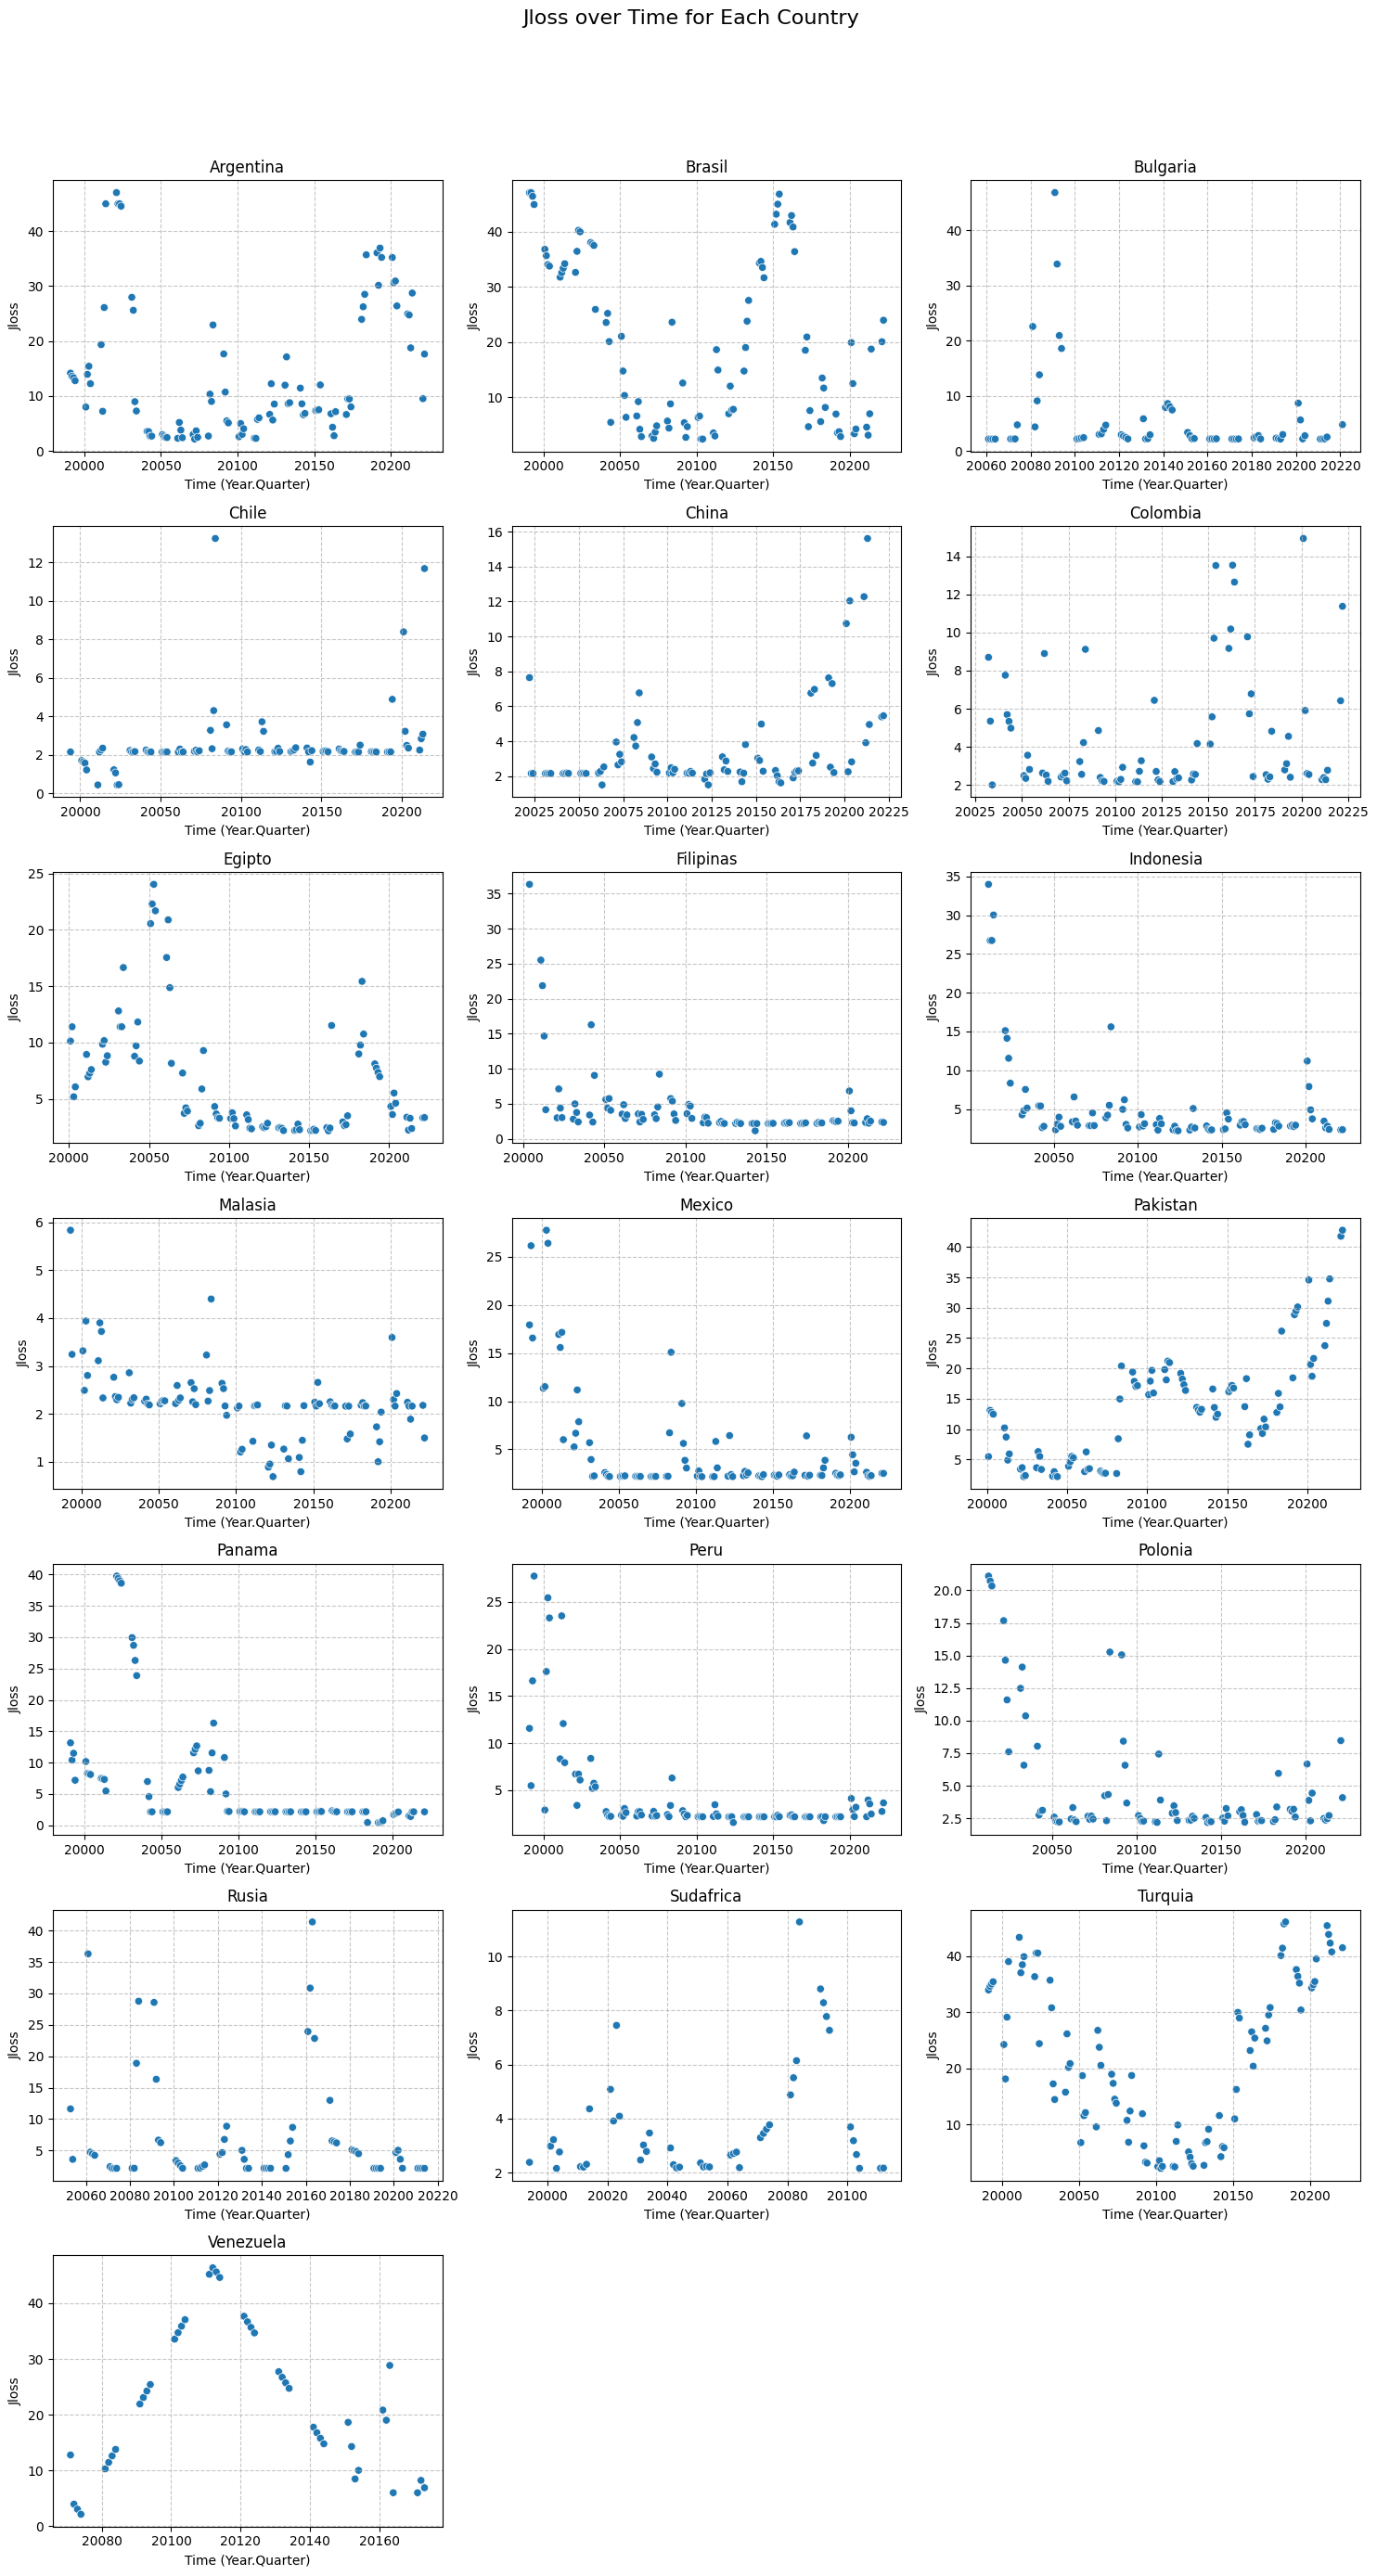

In [82]:
# Get unique countries
countries = df['country'].unique()

# Determine grid size for subplots
num_countries = len(countries)
num_cols = 3  # You can adjust this number based on how many plots you want per row
num_rows = (num_countries + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 5, num_rows * 4))
plt.suptitle('Jloss over Time for Each Country', fontsize=16, y=1.02)

for i, country in enumerate(countries):
    plt.subplot(num_rows, num_cols, i + 1)
    country_df = df[df['country'] == country]
    sns.scatterplot(data=country_df, x='time', y='jloss', hue='country', legend=False)
    plt.title(country.capitalize())
    plt.xlabel('Time (Year.Quarter)')
    plt.ylabel('Jloss')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()


## Resumen:

### Hallazgos Clave del Análisis de Datos
* La columna "tiempo" se transformó correctamente al formato numérico "año.trimestre", lo que permite la representación cronológica (por ejemplo, los valores de tiempo originales se convirtieron a números de punto flotante como "1999.099976").
* Las filas que contenían valores "jloss" faltantes se eliminaron del conjunto de datos.
* Se generaron correctamente diagramas de dispersión que ilustran las tendencias de "jloss" a lo largo del tiempo para cada país, con 19 diagramas distintos dispuestos en una cuadrícula, lo que proporciona una visualización clara para cada país.

### Perspectivas o Próximos Pasos
* Las visualizaciones generadas ahora pueden utilizarse para identificar patrones, tendencias o valores atípicos específicos en el rendimiento de "jloss" para cada país a lo largo del tiempo, lo que podría conducir a investigaciones más profundas sobre los factores económicos específicos de cada país.
* Un análisis más profundo podría incluir modelos estadísticos para cuantificar las tendencias observadas o comparar el comportamiento de "jloss" en diferentes países para identificar puntos en común o divergencias.


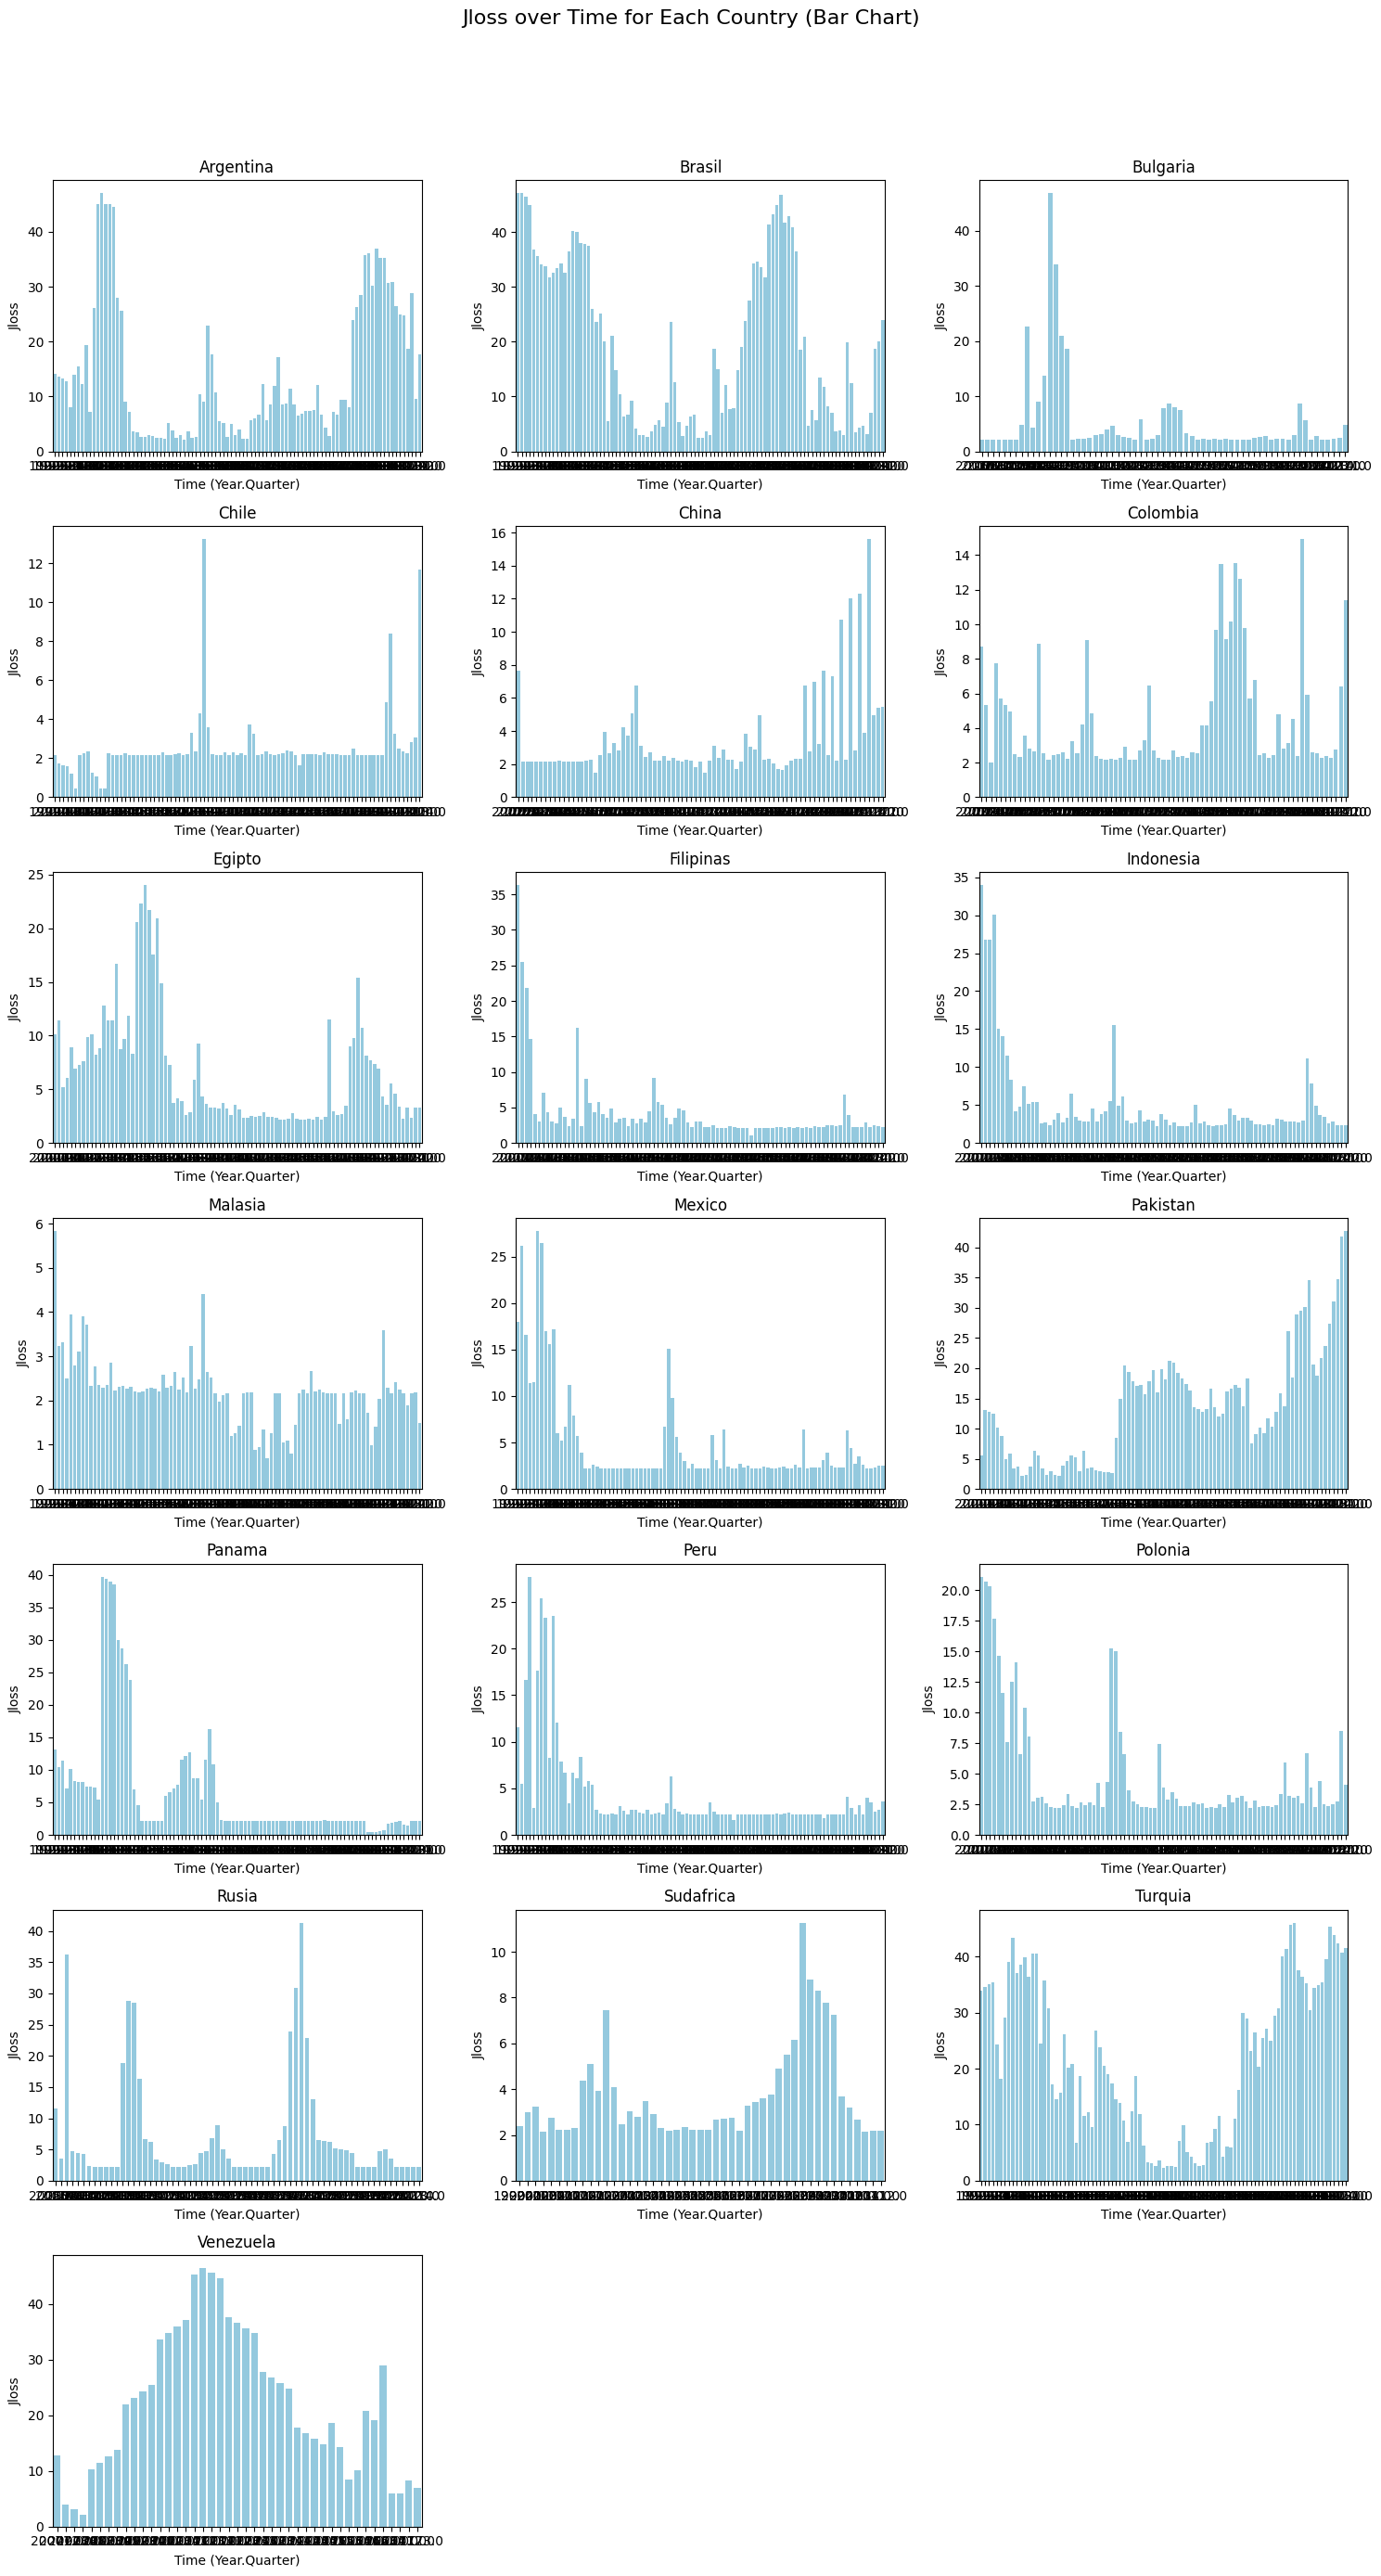

In [83]:
# Get unique countries
countries = df['country'].unique()

# Determine grid size for subplots
num_countries = len(countries)
num_cols = 3  # You can adjust this number based on how many plots you want per row
num_rows = (num_countries + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 5, num_rows * 4))
plt.suptitle('Jloss over Time for Each Country (Bar Chart)', fontsize=16, y=1.02)

for i, country in enumerate(countries):
    plt.subplot(num_rows, num_cols, i + 1)
    country_df = df[df['country'] == country]
    sns.barplot(data=country_df, x='time', y='jloss', color='skyblue') # Changed to barplot
    plt.title(country.capitalize())
    plt.xlabel('Time (Year.Quarter)')
    plt.ylabel('Jloss')


plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

# Unificacion con metricas de GaR del CEMLA

In [84]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

In [109]:
# JLoss (ya cargado, pero lo dejo explícito)
df_jloss = df.copy()

# GaR externo
df_gar_ext = pd.read_csv("growth-at-risk-with-a-pr.csv", sep=";")

# Cambiar nombre de columna Brazil por brasil
df_gar_ext = df_gar_ext.rename(columns={'Brazil': 'brasil'})

In [110]:
# Explorar la estructura actual de df_gar_ext
print("Estructura actual de df_gar_ext:")
print(f"Shape: {df_gar_ext.shape}")
print(f"\nColumnas: {df_gar_ext.columns.tolist()}")
print(f"\nPrimeras filas:")
print(df_gar_ext.head(10))

Estructura actual de df_gar_ext:
Shape: (67, 6)

Columnas: ['Category', 'Colombia', 'brasil', 'Chile', 'México', 'Peru']

Primeras filas:
     Category Colombia   brasil    Chile   México     Peru
0  01/09/2007   3,0921   3,9482   3,0921   3,0921   3,0921
1  01/12/2007   1,1747   2,6613   1,1747   1,1747   1,1747
2  01/03/2008   1,0162    3,265   1,0162   1,0162   1,0162
3  01/06/2008   2,3989   2,4577   1,2683   2,3989   2,3989
4  01/09/2008   2,2937   3,0544   1,2511   2,2937   2,2937
5  01/12/2008  -0,6607    2,921  -0,1211  -1,6628  -1,6628
6  01/03/2009  -6,8046  -5,0193  -4,9598  -5,6771  -5,6771
7  01/06/2009  -5,6244   -6,581  -6,9513  -8,3708  -8,3708
8  01/09/2009  -3,9703  -5,3139  -6,1449  -9,7687  -9,7687
9  01/12/2009  -3,4885   -3,659  -3,5409  -6,0248  -1,3212


In [111]:
# Transformar df_gar_ext de formato ancho a largo con fecha en formato año.trimestre
from datetime import datetime

# Crear una copia para trabajar
df_gar_transformed = df_gar_ext.copy()

# Función para convertir dd/mm/yyyy a año.trimestre
def date_to_year_quarter(date_str):
    """
    Convierte una fecha en formato dd/mm/yyyy a año.trimestre
    donde trimestre es 1, 2, 3, 4
    Ejemplos: 2007.3 (Q3 2007), 2007.4 (Q4 2007), 2008.1 (Q1 2008)
    """
    try:
        date_obj = datetime.strptime(date_str, '%d/%m/%Y')
        year = date_obj.year
        month = date_obj.month
        
        # Determinar el trimestre (1-4)
        quarter = (month - 1) // 3 + 1  # 1, 2, 3, 4
        
        # Formato: año + trimestre/10 para obtener año.trimestre
        year_quarter = year + quarter / 10.0
        
        return year_quarter
    except:
        return None

# Aplicar la conversión de fechas
df_gar_transformed['time_raw'] = df_gar_transformed['Category'].apply(date_to_year_quarter)

# Renombrar la columna Category a mantenerla como referencia
df_gar_transformed = df_gar_transformed.drop('Category', axis=1)

# Convertir de formato ancho a largo
countries_cols = ['Colombia', 'brasil', 'Chile', 'México', 'Peru']
df_gar_long = df_gar_transformed.melt(
    id_vars=['time_raw'],
    value_vars=countries_cols,
    var_name='country',
    value_name='GaR'
)

# Limpiar los valores GaR (convertir comas a puntos si es necesario)
df_gar_long['GaR'] = df_gar_long['GaR'].astype(str).str.replace(',', '.').astype(float)

# Aplicar la transformación de tiempo según la fórmula: time = (time // 10) + (time % 10) / 10.0
# Convertir time_raw a entero multiplicado por 10 para la operación
time = (df_gar_long['time_raw'] * 10).astype(int)
df_gar_long['time'] = time

# Seleccionar solo las columnas finales en el orden deseado
df_gar_ext = df_gar_long[['country', 'time', 'GaR']].copy()

# Convertir country a minúsculas para que coincida con df_jloss
df_gar_ext['country'] = df_gar_ext['country'].str.lower()

print("Transformación completada. Nueva estructura de df_gar_ext:")
print(f"Shape: {df_gar_ext.shape}")
print(f"Columnas: {df_gar_ext.columns.tolist()}")
print(f"\nPrimeras filas:")
print(df_gar_ext.head(20))
print(f"\nÚltimas filas:")
print(df_gar_ext.tail(10))

Transformación completada. Nueva estructura de df_gar_ext:
Shape: (335, 3)
Columnas: ['country', 'time', 'GaR']

Primeras filas:
     country   time     GaR
0   colombia  20073  3.0921
1   colombia  20074  1.1747
2   colombia  20081  1.0162
3   colombia  20082  2.3989
4   colombia  20083  2.2937
5   colombia  20084 -0.6607
6   colombia  20091 -6.8046
7   colombia  20092 -5.6244
8   colombia  20093 -3.9703
9   colombia  20094 -3.4885
10  colombia  20101 -0.0613
11  colombia  20102  1.0761
12  colombia  20103  1.7633
13  colombia  20104  1.2793
14  colombia  20111  3.4271
15  colombia  20112  5.1846
16  colombia  20113  5.1636
17  colombia  20114  5.4459
18  colombia  20121  3.7300
19  colombia  20122  4.2053

Últimas filas:
    country   time      GaR
325    peru  20214   2.4848
326    peru  20221  -1.0528
327    peru  20222  -4.5351
328    peru  20223 -12.8587
329    peru  20224  -8.4331
330    peru  20231  -2.4000
331    peru  20232  -5.1227
332    peru  20233  -3.5154
333    peru  20

In [121]:
print("Tabla final de df_gar_ext después de aplicar la transformación:")
print(f"Shape: {df_gar_ext.shape}")
print(f"\nPrimeras filas:")
print(df_gar_ext.head(20))
print(f"\nÚltimas filas:")
print(df_gar_ext.tail(10))
print(f"\nResumen estadístico:")
print(df_gar_ext.describe())

Tabla final de df_gar_ext después de aplicar la transformación:
Shape: (335, 3)

Primeras filas:
     country   time     GaR
0   colombia  20073  3.0921
1   colombia  20074  1.1747
2   colombia  20081  1.0162
3   colombia  20082  2.3989
4   colombia  20083  2.2937
5   colombia  20084 -0.6607
6   colombia  20091 -6.8046
7   colombia  20092 -5.6244
8   colombia  20093 -3.9703
9   colombia  20094 -3.4885
10  colombia  20101 -0.0613
11  colombia  20102  1.0761
12  colombia  20103  1.7633
13  colombia  20104  1.2793
14  colombia  20111  3.4271
15  colombia  20112  5.1846
16  colombia  20113  5.1636
17  colombia  20114  5.4459
18  colombia  20121  3.7300
19  colombia  20122  4.2053

Últimas filas:
    country   time      GaR
325    peru  20214   2.4848
326    peru  20221  -1.0528
327    peru  20222  -4.5351
328    peru  20223 -12.8587
329    peru  20224  -8.4331
330    peru  20231  -2.4000
331    peru  20232  -5.1227
332    peru  20233  -3.5154
333    peru  20234  -4.0737
334    peru  20241 

# Sovereign Credit Spreads

In [162]:
df_spreads = pd.read_excel("Serie_Historica_Spread_del_EMBI.xlsx")

In [163]:
# Explorar la estructura actual de df_spreads
print("Estructura actual de df_spreads:")
print(f"Shape: {df_spreads.shape}")
print(f"\nColumnas: {df_spreads.columns.tolist()}")
print(f"\nPrimeras filas:")
print(df_spreads.head(10))

Estructura actual de df_spreads:
Shape: (4524, 28)

Columnas: ['EMBI Global Diversified Subindices', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27']

Primeras filas:
  EMBI Global Diversified Subindices Unnamed: 1 Unnamed: 2 Unnamed: 3  \
0                              Fecha     Global     LATINO    REP DOM   
1                2007-10-29 00:00:00    2.10117    2.32541    2.28217   
2                2007-10-30 00:00:00    2.09184    2.30653    2.28059   
3                2007-10-31 00:00:00     2.0105    2.20068    2.13124   
4                2007-11-01 00:00:00    2.12474    2.31998    2.22515   
5                2007-11-02 00:00:00    2.20092 

In [164]:
# Cambiar nombres de columnas usando la primera fila
print("Nombres actuales de columnas:")
print(df_spreads.columns.tolist())
print(f"\nPrimera fila (que serán los nuevos nombres de columnas):")
print(df_spreads.iloc[0].tolist())

# Usar la primera fila como nombres de columnas
df_spreads.columns = df_spreads.iloc[0]

# Eliminar la primera fila ya que ahora es el header
df_spreads = df_spreads.iloc[1:].reset_index(drop=True)

print(f"\nNuevos nombres de columnas:")
print(df_spreads.columns.tolist())
print(f"\nShape después del cambio: {df_spreads.shape}")
print(f"\nPrimeras filas del dataframe con nuevos nombres:")
print(df_spreads.head(5))

Nombres actuales de columnas:
['EMBI Global Diversified Subindices', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27']

Primera fila (que serán los nuevos nombres de columnas):
['Fecha', 'Global', 'LATINO', 'REP DOM', 'Argentina', 'Bolivia', 'Brasil', 'Chile', 'Colombia', 'Costa Rica', 'Ecuador', 'El Salvador', 'Guatemala', 'Honduras', 'México', 'Paraguay', 'Perú', 'Panamá', 'Uruguay', 'Venezuela', 'RD-LATINO', np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]

Nuevos nombres de columnas:
['Fecha', 'Global', 'LATINO', 'REP DOM', 'Argentina', 'Bolivia', 'Brasil', 'Chile', 'Colomb

In [165]:
# Borrar las últimas 7 columnas del dataframe df_spreads
print(f"Columnas actuales ({len(df_spreads.columns)}):")
print(df_spreads.columns.tolist())

# Seleccionar las últimas 7 columnas para borrar
columns_to_drop = df_spreads.columns[-7:]
print(f"\nColumnas que se van a borrar ({len(columns_to_drop)}):")
print(columns_to_drop.tolist())

# Borrar las columnas
df_spreads = df_spreads.drop(columns=columns_to_drop)

print(f"\nColumnas restantes ({len(df_spreads.columns)}):")
print(df_spreads.columns.tolist())
print(f"\nShape después de borrar columnas: {df_spreads.shape}")
print(f"\nPrimeras filas del dataframe:")
print(df_spreads.head(3))

Columnas actuales (28):
['Fecha', 'Global', 'LATINO', 'REP DOM', 'Argentina', 'Bolivia', 'Brasil', 'Chile', 'Colombia', 'Costa Rica', 'Ecuador', 'El Salvador', 'Guatemala', 'Honduras', 'México', 'Paraguay', 'Perú', 'Panamá', 'Uruguay', 'Venezuela', 'RD-LATINO', np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]

Columnas que se van a borrar (7):
[np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]

Columnas restantes (21):
['Fecha', 'Global', 'LATINO', 'REP DOM', 'Argentina', 'Bolivia', 'Brasil', 'Chile', 'Colombia', 'Costa Rica', 'Ecuador', 'El Salvador', 'Guatemala', 'Honduras', 'México', 'Paraguay', 'Perú', 'Panamá', 'Uruguay', 'Venezuela', 'RD-LATINO']

Shape después de borrar columnas: (4523, 21)

Primeras filas del dataframe:
0                Fecha   Global   LATINO  REP DOM Argentina Bolivia   Brasil  \
0  2007-10-29 00:00:00  2.10117  2.32541  2

In [166]:
# Analizar las características de la columna Fecha
print("=== ANÁLISIS DE LA COLUMNA FECHA ===")
print(f"Tipo de dato de la columna Fecha: {df_spreads['Fecha'].dtype}")
print(f"Número total de fechas: {len(df_spreads['Fecha'])}")
print(f"Número de valores únicos: {df_spreads['Fecha'].nunique()}")

# Convertir a datetime si no lo está
if not pd.api.types.is_datetime64_any_dtype(df_spreads['Fecha']):
    df_spreads['Fecha'] = pd.to_datetime(df_spreads['Fecha'], errors='coerce')
    print("Columna Fecha convertida a datetime")

print(f"\nPrimera fecha: {df_spreads['Fecha'].min()}")
print(f"Última fecha: {df_spreads['Fecha'].max()}")

# Calcular el rango de fechas
date_range = df_spreads['Fecha'].max() - df_spreads['Fecha'].min()
print(f"Rango total: {date_range}")

# Verificar si hay fechas faltantes
print(f"\nValores nulos en Fecha: {df_spreads['Fecha'].isnull().sum()}")

# Mostrar las primeras y últimas fechas
print(f"\nPrimeras 5 fechas:")
print(df_spreads['Fecha'].head())
print(f"\nÚltimas 5 fechas:")
print(df_spreads['Fecha'].tail())

# Estadísticas adicionales
print(f"\nEstadísticas de fechas:")
print(f"Año mínimo: {df_spreads['Fecha'].dt.year.min()}")
print(f"Año máximo: {df_spreads['Fecha'].dt.year.max()}")
print(f"Meses únicos: {sorted(df_spreads['Fecha'].dt.month.unique())}")

=== ANÁLISIS DE LA COLUMNA FECHA ===
Tipo de dato de la columna Fecha: object
Número total de fechas: 4523
Número de valores únicos: 4523
Columna Fecha convertida a datetime

Primera fecha: 2007-10-29 00:00:00
Última fecha: 2025-12-17 00:00:00
Rango total: 6624 days 00:00:00

Valores nulos en Fecha: 0

Primeras 5 fechas:
0   2007-10-29
1   2007-10-30
2   2007-10-31
3   2007-11-01
4   2007-11-02
Name: Fecha, dtype: datetime64[ns]

Últimas 5 fechas:
4518   2025-12-11
4519   2025-12-12
4520   2025-12-15
4521   2025-12-16
4522   2025-12-17
Name: Fecha, dtype: datetime64[ns]

Estadísticas de fechas:
Año mínimo: 2007
Año máximo: 2025
Meses únicos: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


In [167]:
# Seleccionar las columnas de Brasil, Chile, Colombia y Perú junto con Fecha
paises_seleccionados = ['Fecha', 'Brasil', 'Chile', 'Colombia', 'Perú']

print("Columnas disponibles:")
print(df_spreads.columns.tolist())
print(f"\nColumnas que se van a seleccionar: {paises_seleccionados}")

# Verificar que todas las columnas existen
missing_cols = [col for col in paises_seleccionados if col not in df_spreads.columns]
if missing_cols:
    print(f"\n⚠️  Columnas faltantes: {missing_cols}")
else:
    print("\n✅ Todas las columnas están disponibles")

# Seleccionar las columnas
df_spreads_selected = df_spreads[paises_seleccionados].copy()

print(f"\nShape del dataframe original: {df_spreads.shape}")
print(f"Shape del dataframe seleccionado: {df_spreads_selected.shape}")
print(f"\nPrimeras filas del dataframe seleccionado:")
print(df_spreads_selected.head())
print(f"\nÚltimas filas del dataframe seleccionado:")
print(df_spreads_selected.tail())

# Estadísticas básicas
print(f"\nEstadísticas de valores nulos por columna:")
print(df_spreads_selected.isnull().sum())

print(f"\nResumen estadístico de las columnas numéricas:")
print(df_spreads_selected.describe())

Columnas disponibles:
['Fecha', 'Global', 'LATINO', 'REP DOM', 'Argentina', 'Bolivia', 'Brasil', 'Chile', 'Colombia', 'Costa Rica', 'Ecuador', 'El Salvador', 'Guatemala', 'Honduras', 'México', 'Paraguay', 'Perú', 'Panamá', 'Uruguay', 'Venezuela', 'RD-LATINO']

Columnas que se van a seleccionar: ['Fecha', 'Brasil', 'Chile', 'Colombia', 'Perú']

✅ Todas las columnas están disponibles

Shape del dataframe original: (4523, 21)
Shape del dataframe seleccionado: (4523, 5)

Primeras filas del dataframe seleccionado:
0      Fecha   Brasil    Chile Colombia     Perú
0 2007-10-29  1.74591  1.12264   1.6012  1.45609
1 2007-10-30  1.73399  1.12886  1.57447  1.45076
2 2007-10-31  1.65654  1.11809  1.47853  1.36579
3 2007-11-01  1.78215  1.09782  1.60699  1.45911
4 2007-11-02  1.85498  1.14779  1.68363  1.52888

Últimas filas del dataframe seleccionado:
0         Fecha   Brasil    Chile Colombia     Perú
4518 2025-12-11  1.99566  0.90876  2.79045  1.24313
4519 2025-12-12  1.96222  0.87174  2.76155  

In [168]:
# Agregar columna 'fecha' con el trimestre correspondiente
def get_quarter(date):
    """
    Determina el trimestre basado en la fecha
    Retorna el trimestre en formato '1T', '2T', '3T', '4T'
    """
    month = date.month

    if month <= 3:
        return '1T'  # Trimestre 1: enero-marzo
    elif month <= 6:
        return '2T'  # Trimestre 2: abril-junio
    elif month <= 9:
        return '3T'  # Trimestre 3: julio-septiembre
    else:
        return '4T'  # Trimestre 4: octubre-diciembre

# Agregar la nueva columna 'fecha' con los trimestres
df_spreads_selected['fecha'] = df_spreads_selected['Fecha'].apply(get_quarter)

print("Nueva columna 'fecha' agregada con trimestres:")
print(f"Shape del dataframe: {df_spreads_selected.shape}")
print(f"\nColumnas: {df_spreads_selected.columns.tolist()}")
print(f"\nPrimeras filas:")
print(df_spreads_selected.head(10))
print(f"\nÚltimas filas:")
print(df_spreads_selected.tail(10))

# Verificar la distribución de trimestres
print(f"\nDistribución de trimestres:")
print(df_spreads_selected['fecha'].value_counts().sort_index())

# Verificar que la columna Fecha siga siendo datetime
print(f"\nTipo de dato de Fecha: {df_spreads_selected['Fecha'].dtype}")
print(f"Tipo de dato de fecha: {df_spreads_selected['fecha'].dtype}")

Nueva columna 'fecha' agregada con trimestres:
Shape del dataframe: (4523, 6)

Columnas: ['Fecha', 'Brasil', 'Chile', 'Colombia', 'Perú', 'fecha']

Primeras filas:
0      Fecha   Brasil    Chile Colombia     Perú fecha
0 2007-10-29  1.74591  1.12264   1.6012  1.45609    4T
1 2007-10-30  1.73399  1.12886  1.57447  1.45076    4T
2 2007-10-31  1.65654  1.11809  1.47853  1.36579    4T
3 2007-11-01  1.78215  1.09782  1.60699  1.45911    4T
4 2007-11-02  1.85498  1.14779  1.68363  1.52888    4T
5 2007-11-05   1.8496  1.14929  1.66223  1.50675    4T
6 2007-11-06  1.83288  1.15067  1.65152  1.51148    4T
7 2007-11-07   1.9013  1.15693  1.75928  1.54806    4T
8 2007-11-08  1.99107  1.23566  1.84754  1.63311    4T
9 2007-11-09  2.01532   1.2342  1.87895  1.66699    4T

Últimas filas:
0         Fecha   Brasil    Chile Colombia     Perú fecha
4513 2025-12-04  1.92192  0.92051  2.70383  1.21034    4T
4514 2025-12-05  1.96956  0.89767  2.67698  1.20828    4T
4515 2025-12-08  1.99136  0.90253  2.7431

In [169]:
# Crear nueva columna que combine año + trimestre (ej: 20094 para 2009 4T)
def create_year_quarter(date, quarter_str):
    """
    Combina el año de la fecha con el número del trimestre
    Ejemplo: 2009 + '4T' = 20094
    """
    year = date.year
    quarter_num = quarter_str[0]  # Extrae el número del trimestre ('4T' -> '4')
    return int(f"{year}{quarter_num}")

# Crear la nueva columna
df_spreads_selected['year_quarter'] = df_spreads_selected.apply(
    lambda row: create_year_quarter(row['Fecha'], row['fecha']), axis=1
)

print("Nueva columna 'year_quarter' creada:")
print(f"Shape del dataframe: {df_spreads_selected.shape}")
print(f"\nColumnas: {df_spreads_selected.columns.tolist()}")
print(f"\nPrimeras filas:")
print(df_spreads_selected[['Fecha', 'fecha', 'year_quarter']].head(10))
print(f"\nÚltimas filas:")
print(df_spreads_selected[['Fecha', 'fecha', 'year_quarter']].tail(10))

# Verificar algunos ejemplos específicos
print(f"\nEjemplos específicos:")
print(f"Fecha 2007-10-29 (4T) -> year_quarter: {df_spreads_selected.loc[0, 'year_quarter']}")
print(f"Fecha 2008-01-02 (1T) -> year_quarter: {df_spreads_selected[df_spreads_selected['Fecha'].dt.year == 2008].iloc[0]['year_quarter']}")

# Estadísticas de la nueva columna
print(f"\nEstadísticas de year_quarter:")
print(f"Valor mínimo: {df_spreads_selected['year_quarter'].min()}")
print(f"Valor máximo: {df_spreads_selected['year_quarter'].max()}")
print(f"Valores únicos: {df_spreads_selected['year_quarter'].nunique()}")

print(f"\nTipo de dato de year_quarter: {df_spreads_selected['year_quarter'].dtype}")

Nueva columna 'year_quarter' creada:
Shape del dataframe: (4523, 7)

Columnas: ['Fecha', 'Brasil', 'Chile', 'Colombia', 'Perú', 'fecha', 'year_quarter']

Primeras filas:
0      Fecha fecha  year_quarter
0 2007-10-29    4T         20074
1 2007-10-30    4T         20074
2 2007-10-31    4T         20074
3 2007-11-01    4T         20074
4 2007-11-02    4T         20074
5 2007-11-05    4T         20074
6 2007-11-06    4T         20074
7 2007-11-07    4T         20074
8 2007-11-08    4T         20074
9 2007-11-09    4T         20074

Últimas filas:
0         Fecha fecha  year_quarter
4513 2025-12-04    4T         20254
4514 2025-12-05    4T         20254
4515 2025-12-08    4T         20254
4516 2025-12-09    4T         20254
4517 2025-12-10    4T         20254
4518 2025-12-11    4T         20254
4519 2025-12-12    4T         20254
4520 2025-12-15    4T         20254
4521 2025-12-16    4T         20254
4522 2025-12-17    4T         20254

Ejemplos específicos:
Fecha 2007-10-29 (4T) -> year_qu

In [170]:
# Crear dataframe agregado con spreads promedio por trimestre y país
print("=== CREANDO DATAFRAME DE SPREADS PROMEDIO POR TRIMESTRE ===")

# Primero, convertir el dataframe de formato ancho a largo
country_columns = ['Brasil', 'Chile', 'Colombia', 'Perú']

# Crear dataframe largo con spreads
df_spreads_long = df_spreads_selected.melt(
    id_vars=['year_quarter'],
    value_vars=country_columns,
    var_name='country',
    value_name='spread'
)

print("Dataframe en formato largo:")
print(f"Shape: {df_spreads_long.shape}")
print(f"Columnas: {df_spreads_long.columns.tolist()}")
print(f"\nPrimeras filas:")
print(df_spreads_long.head(10))

# Verificar valores nulos antes de la conversión
print(f"\nValores nulos en spread antes de conversión: {df_spreads_long['spread'].isnull().sum()}")

# Convertir la columna spread a numérico, forzando errores a NaN
df_spreads_long['spread'] = pd.to_numeric(df_spreads_long['spread'], errors='coerce')

print(f"Valores nulos en spread después de conversión: {df_spreads_long['spread'].isnull().sum()}")
print(f"Tipo de dato de spread: {df_spreads_long['spread'].dtype}")

# Si hay valores nulos, los excluiremos del promedio
df_spreads_long_clean = df_spreads_long.dropna(subset=['spread'])

print(f"\nDespués de eliminar nulos - Shape: {df_spreads_long_clean.shape}")

# Agrupar por country y year_quarter y calcular el promedio del spread
df_spreads_avg = df_spreads_long_clean.groupby(['country', 'year_quarter'])['spread'].mean().reset_index()

# Renombrar columnas según lo solicitado: country, fecha, spread
df_spreads_avg = df_spreads_avg.rename(columns={'year_quarter': 'fecha'})

print(f"\n=== DATAFRAME FINAL DE SPREADS PROMEDIO ===")
print(f"Shape: {df_spreads_avg.shape}")
print(f"Columnas: {df_spreads_avg.columns.tolist()}")
print(f"\nPrimeras filas:")
print(df_spreads_avg.head(15))
print(f"\nÚltimas filas:")
print(df_spreads_avg.tail(15))

# Estadísticas del dataframe final
print(f"\nEstadísticas del dataframe final:")
print(f"Número de países únicos: {df_spreads_avg['country'].nunique()}")
print(f"Número de trimestres únicos: {df_spreads_avg['fecha'].nunique()}")
print(f"Rango de fechas: {df_spreads_avg['fecha'].min()} - {df_spreads_avg['fecha'].max()}")
print(f"Spread promedio general: {df_spreads_avg['spread'].mean():.4f}")
print(f"Spread mínimo: {df_spreads_avg['spread'].min():.4f}")
print(f"Spread máximo: {df_spreads_avg['spread'].max():.4f}")

# Verificar que tenemos datos para todos los países y trimestres esperados
print(f"\nDistribución por país:")
print(df_spreads_avg['country'].value_counts())

print(f"\nMuestra de spreads por país y trimestre:")
for country in df_spreads_avg['country'].unique():
    country_data = df_spreads_avg[df_spreads_avg['country'] == country]
    print(f"\n{country}: {len(country_data)} trimestres")
    print(f"  Rango fechas: {country_data['fecha'].min()} - {country_data['fecha'].max()}")
    print(f"  Spread promedio: {country_data['spread'].mean():.4f}")

=== CREANDO DATAFRAME DE SPREADS PROMEDIO POR TRIMESTRE ===
Dataframe en formato largo:
Shape: (18092, 3)
Columnas: ['year_quarter', 'country', 'spread']

Primeras filas:
   year_quarter country   spread
0         20074  Brasil  1.74591
1         20074  Brasil  1.73399
2         20074  Brasil  1.65654
3         20074  Brasil  1.78215
4         20074  Brasil  1.85498
5         20074  Brasil   1.8496
6         20074  Brasil  1.83288
7         20074  Brasil   1.9013
8         20074  Brasil  1.99107
9         20074  Brasil  2.01532

Valores nulos en spread antes de conversión: 1
Valores nulos en spread después de conversión: 3
Tipo de dato de spread: float64

Después de eliminar nulos - Shape: (18089, 3)

=== DATAFRAME FINAL DE SPREADS PROMEDIO ===
Shape: (292, 3)
Columnas: ['country', 'fecha', 'spread']

Primeras filas:
   country  fecha    spread
0   Brasil  20074  2.096093
1   Brasil  20081  2.578479
2   Brasil  20082  2.143040
3   Brasil  20083  2.525307
4   Brasil  20084  4.815725
5  

# Merging Databases

In [171]:
# Normalizar nombres
df_spreads_avg["country"] = df_spreads_avg["country"].str.lower().str.strip()
df_spreads_avg["country"] = df_spreads_avg["country"].str.replace('perú', 'peru')  # Cambiar Perú a peru
df_jloss["country"] = df_jloss["country"].str.lower().str.strip()
df_gar_ext["country"] = df_gar_ext["country"].str.lower().str.strip()

In [172]:
# ahora unimos las bases 
df_merged = df_jloss.merge(
    df_gar_ext,
    on=["country", "time"],
    how="inner"   # solo donde hay GaR
)

print(df_merged.info())
print(df_merged.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   time     238 non-null    float32
 1   country  238 non-null    object 
 2   jloss    238 non-null    float64
 3   GaR      238 non-null    float64
dtypes: float32(1), float64(2), object(1)
memory usage: 6.6+ KB
None
      time country     jloss     GaR
0  20073.0  brasil  3.722858  3.9482
1  20074.0  brasil  4.860112  2.6613
2  20081.0  brasil  5.724853  3.2650
3  20082.0  brasil  4.445194  2.4577
4  20083.0  brasil  8.836600  3.0544


In [173]:
# Renombrar 'fecha' a 'time' en df_spreads_avg para que coincida con las otras bases
df_spreads_avg = df_spreads_avg.rename(columns={'fecha': 'time'})

# Ahora unimos df_spreads_avg con df_merged
df_merged = df_merged.merge(
    df_spreads_avg,
    on=["country", "time"],
    how="inner"   # solo donde hay datos de spreads
)

print("DataFrame final después de merge con spreads:")
print(df_merged.info())
print(df_merged.head())

DataFrame final después de merge con spreads:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   time     234 non-null    float32
 1   country  234 non-null    object 
 2   jloss    234 non-null    float64
 3   GaR      234 non-null    float64
 4   spread   234 non-null    float64
dtypes: float32(1), float64(3), object(1)
memory usage: 8.4+ KB
None
      time country      jloss     GaR    spread
0  20074.0  brasil   4.860112  2.6613  2.096093
1  20081.0  brasil   5.724853  3.2650  2.578479
2  20082.0  brasil   4.445194  2.4577  2.143040
3  20083.0  brasil   8.836600  3.0544  2.525307
4  20084.0  brasil  23.632049  2.9210  4.815725


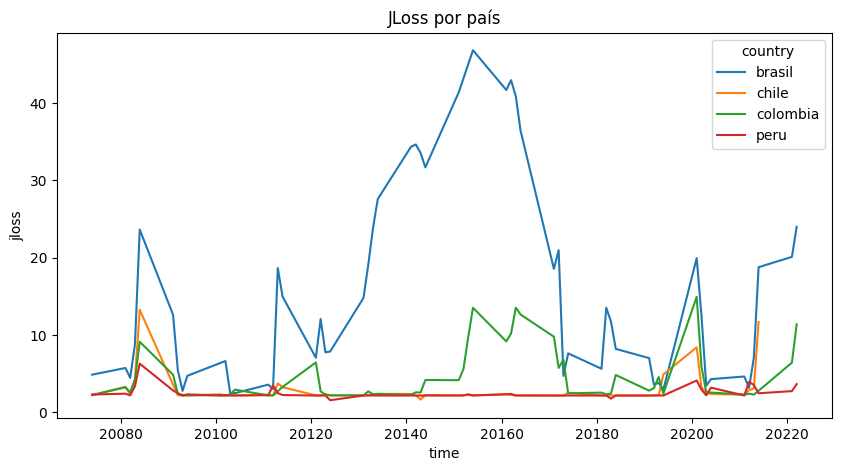

In [174]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_merged,
    x="time",
    y="jloss",
    hue="country"
)
plt.title("JLoss por país")
plt.show()


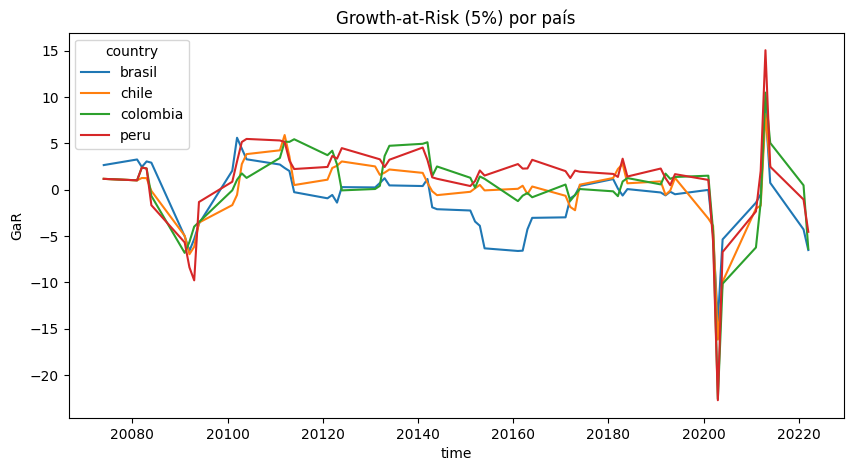

In [175]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_merged,
    x="time",
    y="GaR",
    hue="country"
)
plt.title("Growth-at-Risk (5%) por país")
plt.show()


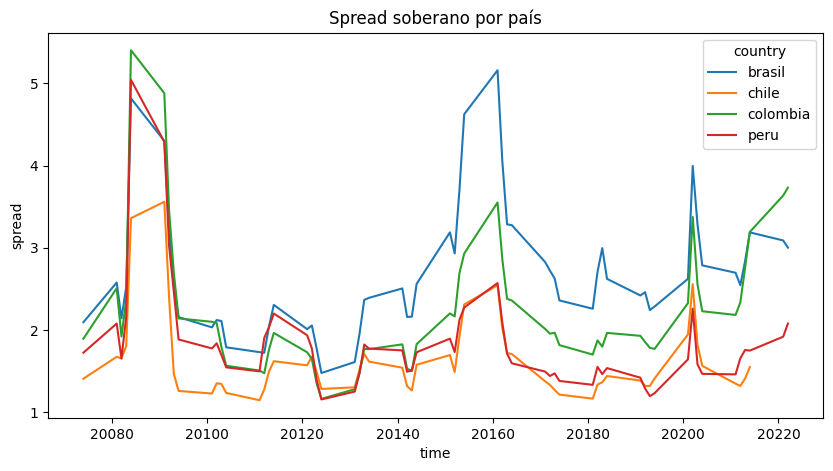

In [177]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_merged,
    x="time",
    y="spread",
    hue="country"
)
plt.title("Spread soberano por país")
plt.show()


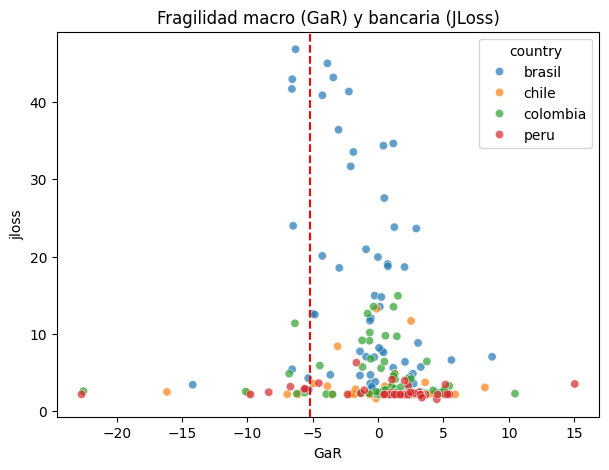

In [178]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_merged,
    x="GaR",
    y="jloss",
    hue="country",
    alpha=0.7
)
plt.axvline(df_merged["GaR"].quantile(0.1), linestyle="--", color="red")
plt.title("Fragilidad macro (GaR) y bancaria (JLoss)")
plt.show()


In [181]:
df_merged.isna().mean()

time       0.0
country    0.0
jloss      0.0
GaR        0.0
spread     0.0
dtype: float64

In [183]:
df_merged["JLoss_x_GaR"] = df_merged["jloss"] * df_merged["GaR"]

# Winsorización (opcional pero recomendado)
for col in ["jloss", "GaR", "spread"]:
    df_merged[col] = df_merged[col].clip(
        df_merged[col].quantile(0.01),
        df_merged[col].quantile(0.99)
    )


In [184]:
df_panel = (df_merged.set_index(["country", "time"]).sort_index())

print(df_panel.info())


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 234 entries, ('brasil', np.float32(20074.0)) to ('peru', np.float32(20222.0))
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   jloss        234 non-null    float64
 1   GaR          234 non-null    float64
 2   spread       234 non-null    float64
 3   JLoss_x_GaR  234 non-null    float64
dtypes: float64(4)
memory usage: 9.8+ KB
None


In [202]:
pooled_formula = """
spread ~ GaR + jloss + JLoss_x_GaR
"""

pooled_res = smf.ols(
    pooled_formula,
    data=df_panel.reset_index()
).fit(cov_type="HC1")

print(pooled_res.summary())

                            OLS Regression Results                            
Dep. Variable:                 spread   R-squared:                       0.375
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     46.78
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           1.22e-23
Time:                        23:53:15   Log-Likelihood:                -221.31
No. Observations:                 234   AIC:                             450.6
Df Residuals:                     230   BIC:                             464.4
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.8399      0.056     33.066      

In [187]:
fe_formula = """
spread ~ 1 + jloss + GaR + JLoss_x_GaR + EntityEffects + TimeEffects
"""

fe_model = PanelOLS.from_formula(
    fe_formula,
    data=df_panel.dropna()
)

fe_res = fe_model.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(fe_res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 spread   R-squared:                        0.2766
Estimator:                   PanelOLS   R-squared (Between):              0.2973
No. Observations:                 234   R-squared (Within):               0.1784
Date:                Thu, Dec 18 2025   R-squared (Overall):              0.2100
Time:                        23:47:41   Log-likelihood                    0.8554
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      21.541
Entities:                           4   P-value                           0.0000
Avg Obs:                       58.500   Distribution:                   F(3,169)
Min Obs:                       57.000                                           
Max Obs:                       59.000   F-statistic (robust):             557.04
                            

# Coberturas minimas

In [190]:
df_panel.reset_index().groupby("country")["time"].agg(["min","max","count"])

,min,max,count
country,,,
brasil,20074.0,20222.0,59
chile,20074.0,20214.0,57
colombia,20074.0,20222.0,59
peru,20074.0,20222.0,59


In [195]:
df_panel[["spread", "jloss", "GaR"]].corr()

,spread,jloss,GaR
spread,1.000000,0.541820,-0.400802
jloss,0.541820,1.000000,-0.229675
GaR,-0.400802,-0.229675,1.000000


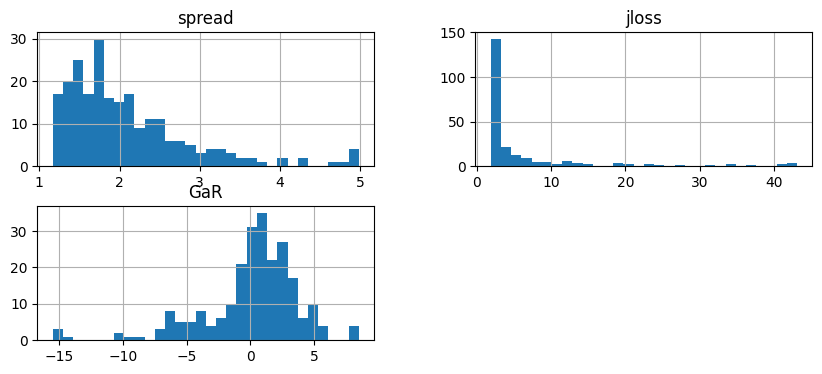

In [192]:
df_panel[["spread", "jloss", "GaR"]].hist(bins=30, figsize=(10,4))
plt.show()

# Outros

In [197]:
fe_spread_formula = """
spread ~ jloss + GaR + JLoss_x_GaR + EntityEffects + TimeEffects
"""

fe_spread_model = PanelOLS.from_formula(
    fe_spread_formula,
    data=df_panel.dropna(subset=["spread"])
)

fe_spread_res = fe_spread_model.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(fe_spread_res.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:                 spread   R-squared:                        0.2766
Estimator:                   PanelOLS   R-squared (Between):              0.0613
No. Observations:                 234   R-squared (Within):               0.1784
Date:                Thu, Dec 18 2025   R-squared (Overall):              0.0722
Time:                        23:51:02   Log-likelihood                    0.8554
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      21.541
Entities:                           4   P-value                           0.0000
Avg Obs:                       58.500   Distribution:                   F(3,169)
Min Obs:                       57.000                                           
Max Obs:                       59.000   F-statistic (robust):             557.04
                            

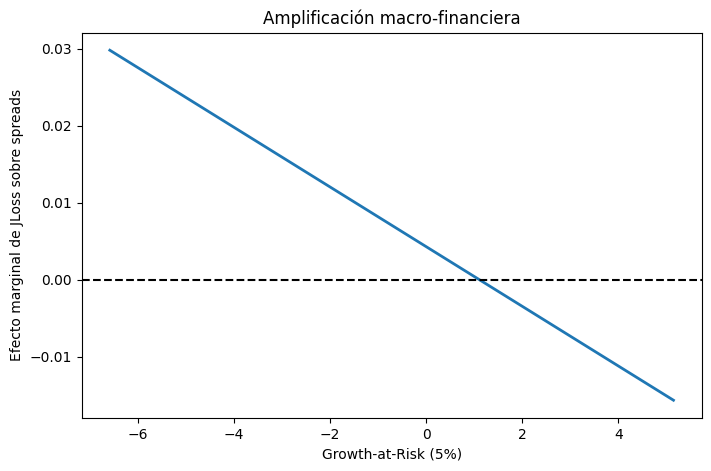

In [200]:
beta_j = fe_spread_res.params["jloss"]
beta_int = fe_spread_res.params["JLoss_x_GaR"]

gar_grid = np.linspace(
    df_panel["GaR"].quantile(0.05),
    df_panel["GaR"].quantile(0.95),
    100
)

marginal_effect = beta_j + beta_int * gar_grid

plt.figure(figsize=(8,5))
plt.plot(gar_grid, marginal_effect, linewidth=2)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Growth-at-Risk (5%)")
plt.ylabel("Efecto marginal de JLoss sobre spreads")
plt.title("Amplificación macro-financiera")
plt.show()
